In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import urllib.request

In [2]:
# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# iris.csv
# Iris (붓꽃) 데이터

# 붓꽃(Iris) 3종 setosa, versicolor, virginica의 측정 데이터

# 측정 대상은
# sepal_length(꽃받침 길이)
# sepal_width(꽃받침 너비)
# petal_length(꽃잎 길이)
# petal_width(꽃잎 너비)

# species(품종)

In [8]:
# Iris — 붓꽃 품종별 꽃잎/꽃받침 측정 데이터
# 컬럼: sepal_length, sepal_width, petal_length, petal_width, species

iris_url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv'
urllib.request.urlretrieve(iris_url, 'iris.csv')

df_iris = pd.read_csv('iris.csv')
print(df_iris.shape)   # (150, 5)
df_iris.head()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
print(df_iris.dtypes)

# species 컬럼: 품종 3종 — setosa / versicolor / virginica
print(df_iris['species'].unique())

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object
<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


In [ ]:
# Titanic — 승객 생존 데이터

# PassengerId: int64/승객 고유 ID
# Survived: int64/생존 여부 — 0 사망, 1 생존
# Pclass: int64/객실 등급 — 1(1등석), 2(2등석), 3(3등석)
# Name: object/승객 이름
# Sex: object/성별 — male/female
# Age: float64/나이 (결측값)
# SibSp: int64/함께 탑승한 형제/배우자 수
# Parch: int64/함께 탑승한 부모/자녀 수
# Ticket: object/티켓 번호
# Fare: float64/티켓 요금
# Cabin: object/객실 번호 (결측값)
# Embarked: object/탑승 항구 — S(Southampton), C(Cherbourg), Q(Queenstown)

# Southampton에서 1912년 4월 10일 출항
# 4월 15일 북대서양에서 빙산과 충돌해 침몰

In [9]:
titanic_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
urllib.request.urlretrieve(titanic_url, 'titanic.csv')

df_titanic = pd.read_csv('titanic.csv')
print(df_titanic.shape)
df_titanic.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
print(df_titanic.isnull().sum())
# df_titanic.isnull()
# 각 컬럼이 결측값(NaN)인지 아닌지를 True/False로 반환
#    PassengerId  Survived  Pclass   Age     Cabin  ...
# 0  False        False     False    False   True  ...
# 1  False        False     False    False   False  ...
# 2  False        False     False    False   True  ...

# True = 1, False = 0 으로 계산, 컬럼별로 합산하면 결측값 개수


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# df_titanic["AGE"].fillna(ㅁ)
# ㅁ ============> df_titanic['AGE'].median()
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())
# 1. df_titanic['Age'].median()
# Age 컬럼의 중간값을 계산

# 2. .fillna(df_titanic['Age'].median())
# Age 컬럼에서 NaN인 셀을 중간값으로 채움

# 3. df_titanic['Age']에 할당

print(df_titanic['Age'].isnull().sum()) # 확인

0


In [12]:
# 2019.csv
# 156개국, 9개 컬럼, 2019년 단일 연도 데이터

# Overall rank: 행복 순위 (1위 = 가장 행복)
# Country or region: 국가명
# Score: 행복 점수
# GDP per capita: 1인당 GDP
# Social support: "내가 힘들 때 기댈 수 있는 사람/친구/지인이 있다"는 느낌의 정도
# Healthy life expectancy: 건강 기대수명
# Freedom to make life choices: "내 삶을 내가 결정할 수 있다"는 느낌의 정도
# Generosity: "지난 한 달 동안 자선단체에 기부한 적이 있습니까?"
# Perceptions of corruption: "정부에 부패가 만연해 있습니까?", "기업에 부패가 만연해 있습니까?"

In [16]:
df_happy = pd.read_csv('2019.csv')

# 상위 20개국만 사용
top20 = df_happy[df_happy['Overall rank'] <= 20].copy()
print(top20[['Overall rank', 'Country or region', 'Score']])

    Overall rank Country or region  Score
0              1           Finland  7.769
1              2           Denmark  7.600
2              3            Norway  7.554
3              4           Iceland  7.494
4              5       Netherlands  7.488
5              6       Switzerland  7.480
6              7            Sweden  7.343
7              8       New Zealand  7.307
8              9            Canada  7.278
9             10           Austria  7.246
10            11         Australia  7.228
11            12        Costa Rica  7.167
12            13            Israel  7.139
13            14        Luxembourg  7.090
14            15    United Kingdom  7.054
15            16           Ireland  7.021
16            17           Germany  6.985
17            18           Belgium  6.923
18            19     United States  6.892
19            20    Czech Republic  6.852


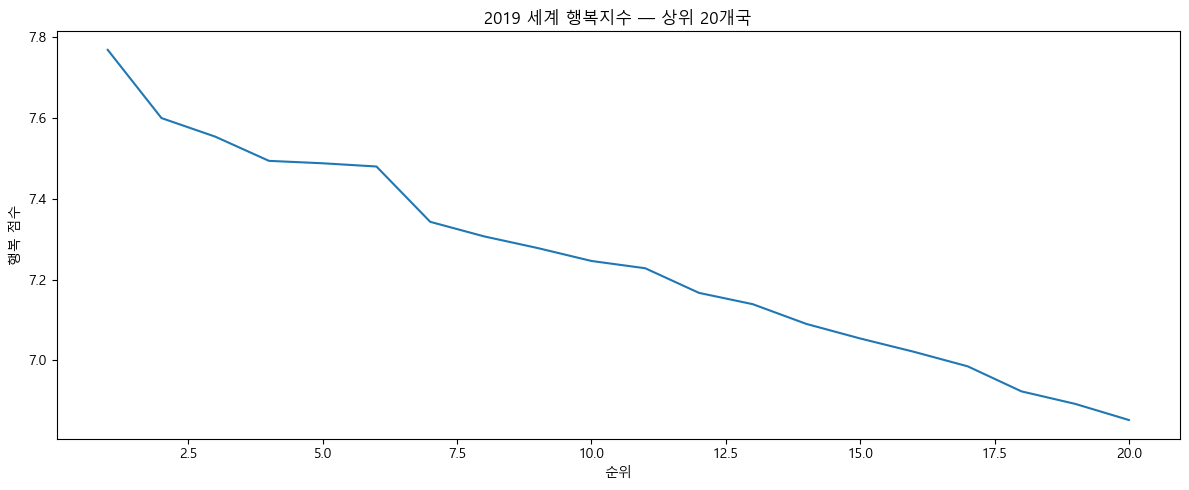

In [17]:
# plt.subplots() — Figure와 Axes를 동시에 생성
fig, ax = plt.subplots(figsize=(12, 5))
# nrows=1, ncols=1가 디폴트

ax.plot(top20['Overall rank'], top20['Score'])

ax.set_title('2019 세계 행복지수 — 상위 20개국')
ax.set_xlabel('순위')
ax.set_ylabel('행복 점수')

plt.tight_layout()
plt.show()

In [18]:
import matplotlib.colors as mcolors

# 기본 색상 (8개)
print(mcolors.BASE_COLORS.keys())

# CSS 색상 (148개)
print(mcolors.CSS4_COLORS.keys())

# Tableau 색상 (10개)
print(mcolors.TABLEAU_COLORS.keys())

dict_keys(['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w'])
dict_keys(['aliceblue', 'antiquewhite', 'aqua', 'aquamarine', 'azure', 'beige', 'bisque', 'black', 'blanchedalmond', 'blue', 'blueviolet', 'brown', 'burlywood', 'cadetblue', 'chartreuse', 'chocolate', 'coral', 'cornflowerblue', 'cornsilk', 'crimson', 'cyan', 'darkblue', 'darkcyan', 'darkgoldenrod', 'darkgray', 'darkgreen', 'darkgrey', 'darkkhaki', 'darkmagenta', 'darkolivegreen', 'darkorange', 'darkorchid', 'darkred', 'darksalmon', 'darkseagreen', 'darkslateblue', 'darkslategray', 'darkslategrey', 'darkturquoise', 'darkviolet', 'deeppink', 'deepskyblue', 'dimgray', 'dimgrey', 'dodgerblue', 'firebrick', 'floralwhite', 'forestgreen', 'fuchsia', 'gainsboro', 'ghostwhite', 'gold', 'goldenrod', 'gray', 'green', 'greenyellow', 'grey', 'honeydew', 'hotpink', 'indianred', 'indigo', 'ivory', 'khaki', 'lavender', 'lavenderblush', 'lawngreen', 'lemonchiffon', 'lightblue', 'lightcoral', 'lightcyan', 'lightgoldenrodyellow', 'lightgray', 'lightgree

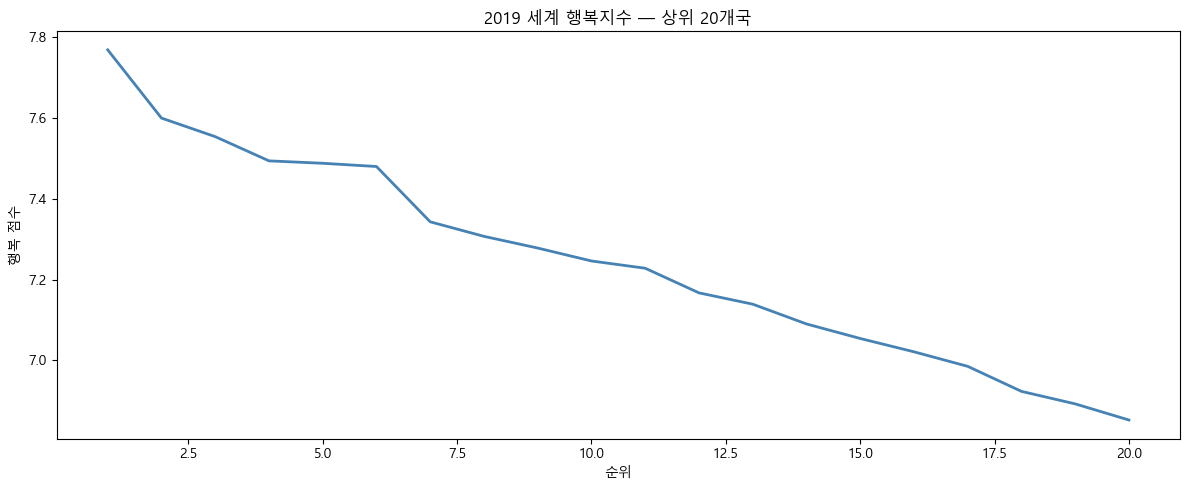

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(top20['Overall rank'], top20['Score'],
        color='steelblue',       # 선 색상
        linewidth=2,             # 선 두께
        linestyle='-')          # 선 종류 — '-', '--', '-.', ':'

ax.set_title('2019 세계 행복지수 — 상위 20개국')
ax.set_xlabel('순위')
ax.set_ylabel('행복 점수')

plt.tight_layout()
plt.show()

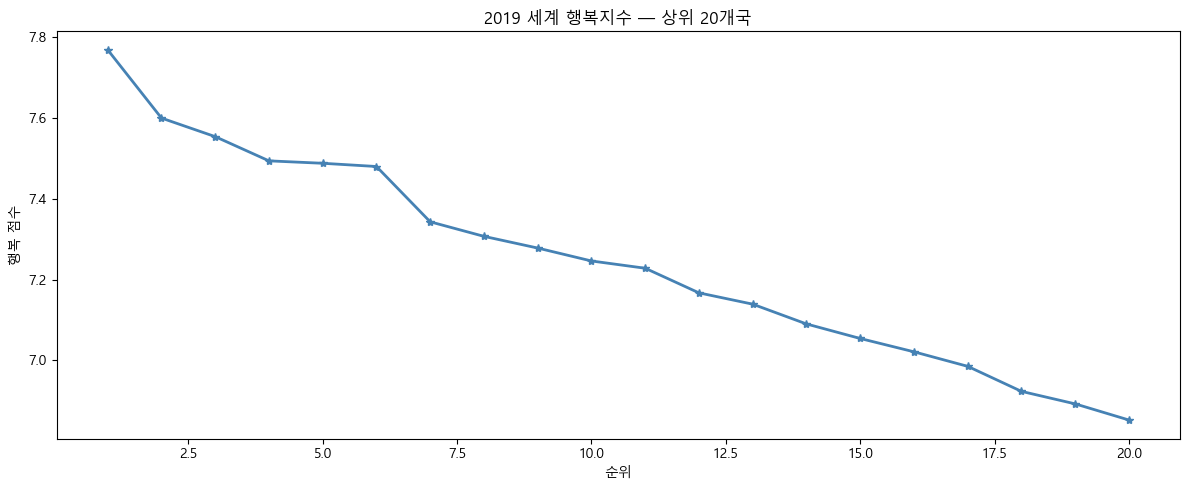

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(top20['Overall rank'], top20['Score'],
        color='steelblue',
        linewidth=2,
        linestyle='-',
        marker='*',              # 마커 모양 — 'o', 's', '^', '*'
        markersize=6)            # 마커 크기

ax.set_title('2019 세계 행복지수 — 상위 20개국')
ax.set_xlabel('순위')
ax.set_ylabel('행복 점수')

plt.tight_layout()
plt.show()

# 마커 모양 — 'o', 's', '^', '*'
# 'o': 원 (circle)
# 's': 정사각형 (square)
# '^': 위 삼각형 (triangle up)
# '*': 별 (star)

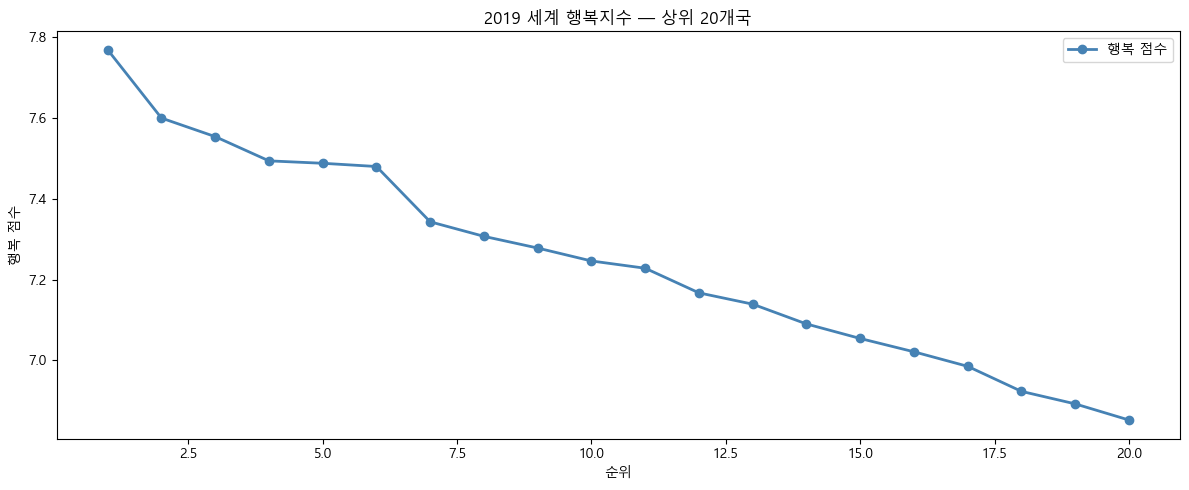

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(top20['Overall rank'], top20['Score'],
        color='steelblue',
        linewidth=2,
        linestyle='-',
        marker='o',
        markersize=6,
        label='행복 점수')       # 범례 이름

ax.set_title('2019 세계 행복지수 — 상위 20개국')
ax.set_xlabel('순위')
ax.set_ylabel('행복 점수')
ax.legend()                     # 범례 표시

plt.tight_layout()
plt.show()

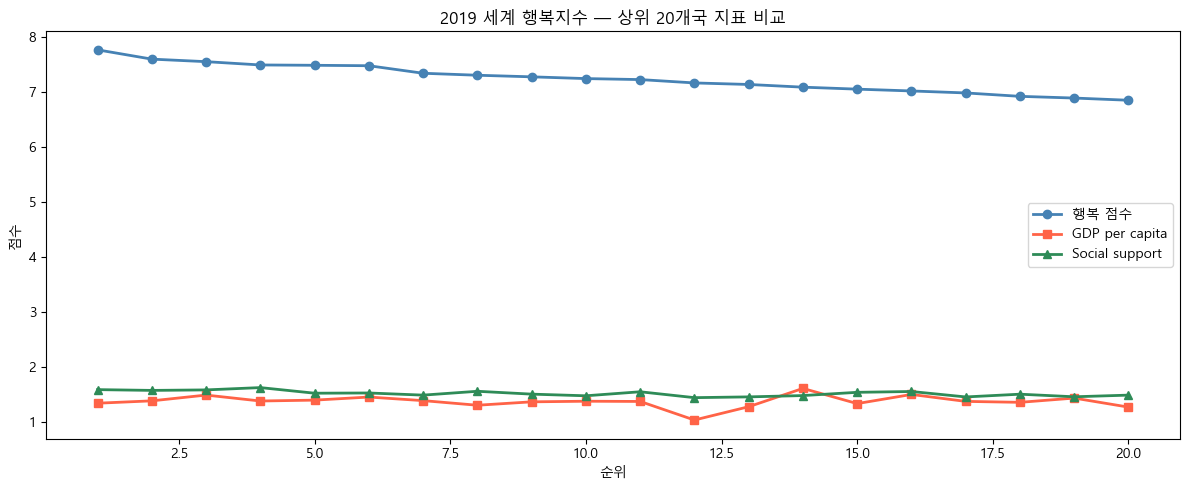

In [29]:
# Score 외에 GDP per capita, Social support도 함께 비교
fig, ax = plt.subplots(figsize=(12, 5))

# 동일한 ax에 ax.plot()을 세 번 호출
ax.plot(top20['Overall rank'], top20['Score'],
        color='steelblue', linewidth=2, marker='o', markersize=6, label='행복 점수')

ax.plot(top20['Overall rank'], top20['GDP per capita'],
        color='tomato', linewidth=2, marker='s', markersize=6, label='GDP per capita')

ax.plot(top20['Overall rank'], top20['Social support'],
        color='seagreen', linewidth=2, marker='^', markersize=6, label='Social support')

ax.set_title('2019 세계 행복지수 — 상위 20개국 지표 비교')
ax.set_xlabel('순위')
ax.set_ylabel('점수')
ax.legend()

plt.tight_layout()
plt.show()

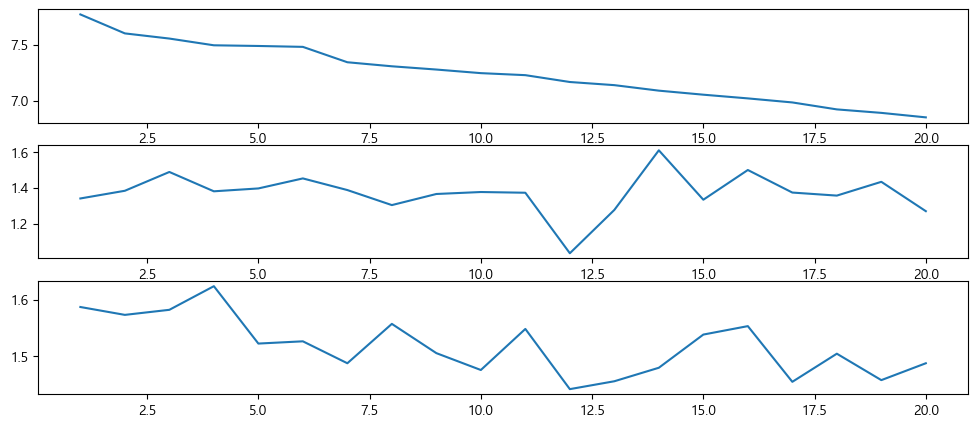

In [30]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 5))  # Axes 3개 생성

axes[0].plot(top20['Overall rank'], top20['Score'])
axes[1].plot(top20['Overall rank'], top20['GDP per capita'])
axes[2].plot(top20['Overall rank'], top20['Social support'])

In [37]:
# 상위 10개국만 사용
top10 = df_happy[df_happy['Overall rank'] <= 10].copy()
top10[['Overall rank', 'Country or region', 'Score']].head(5)

,Overall rank,Country or region,Score
0,1,Finland,7.769
1,2,Denmark,7.600
2,3,Norway,7.554
3,4,Iceland,7.494
4,5,Netherlands,7.488


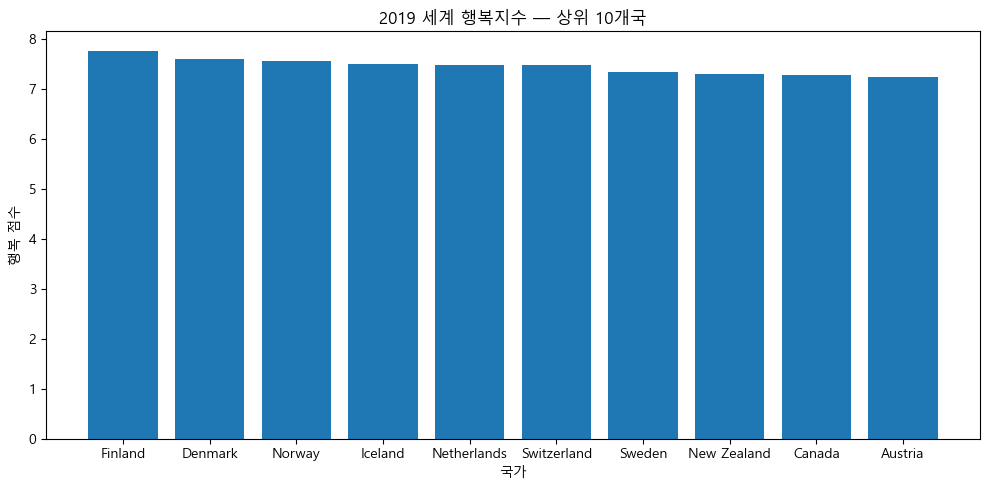

In [38]:
# plt.subplots() — Figure와 Axes를 동시에 생성
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(top10['Country or region'], top10['Score'])

ax.set_title('2019 세계 행복지수 — 상위 10개국')
ax.set_xlabel('국가')
ax.set_ylabel('행복 점수')

plt.tight_layout()
plt.show()

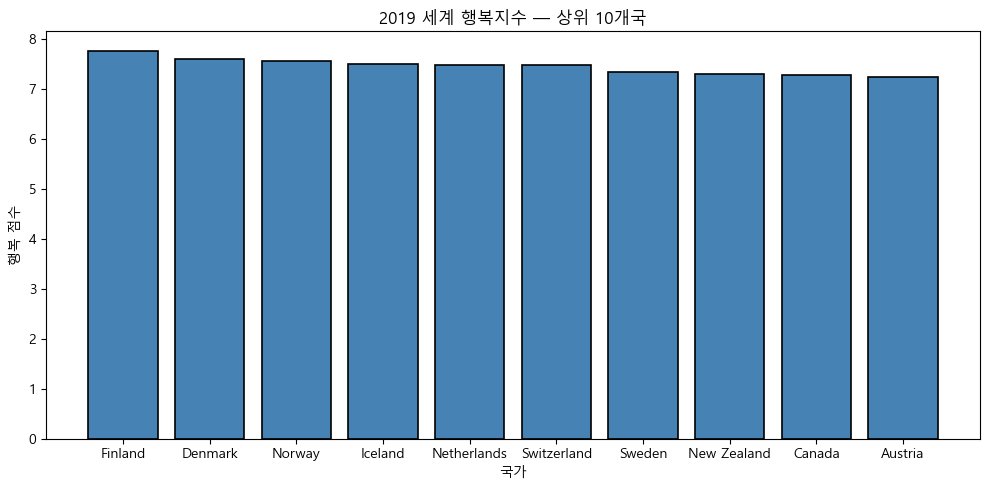

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(top10['Country or region'], top10['Score'],
       color='steelblue',      # 막대 색상
       edgecolor='black',      # 막대 테두리 색상
       linewidth=1.2)          # 막대 테두리 두께

ax.set_title('2019 세계 행복지수 — 상위 10개국')
ax.set_xlabel('국가')
ax.set_ylabel('행복 점수')

plt.tight_layout()
plt.show()

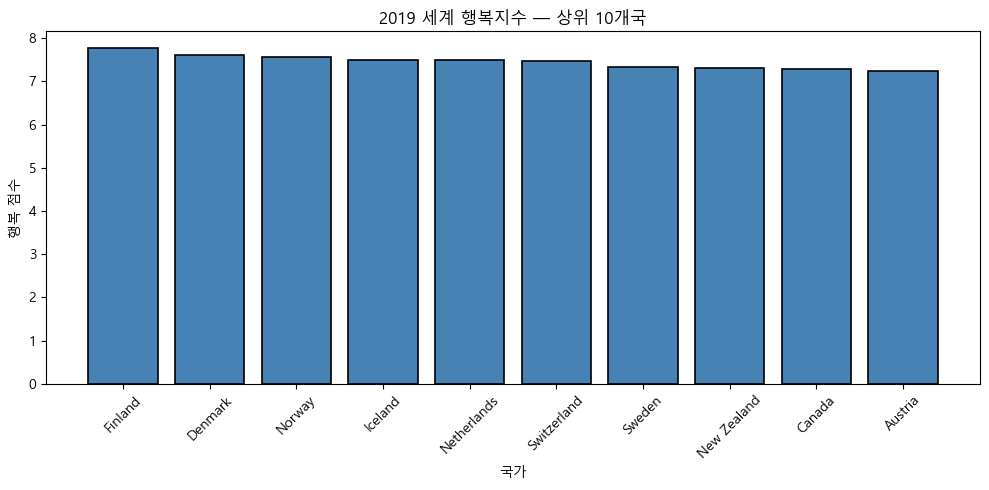

In [39]:
# 국가명이 길어서 겹치는 경우 회전 처리
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(top10['Country or region'], top10['Score'],
       color='steelblue',
       edgecolor='black',
       linewidth=1.2)

ax.set_title('2019 세계 행복지수 — 상위 10개국')
ax.set_xlabel('국가')
ax.set_ylabel('행복 점수')
ax.tick_params(axis='x', rotation=45)  # x축 라벨 45도 회전

plt.tight_layout()
plt.show()

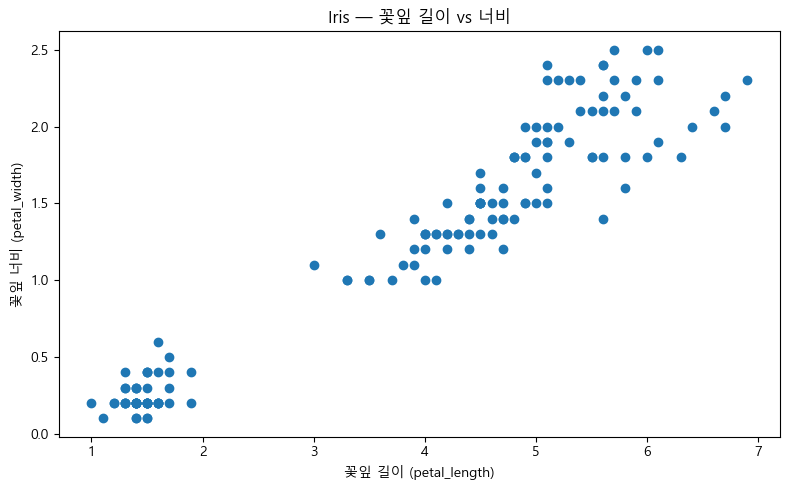

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df_iris['petal_length'], df_iris['petal_width'])

ax.set_title('Iris — 꽃잎 길이 vs 너비')
ax.set_xlabel('꽃잎 길이 (petal_length)')
ax.set_ylabel('꽃잎 너비 (petal_width)')

plt.tight_layout()
plt.show()

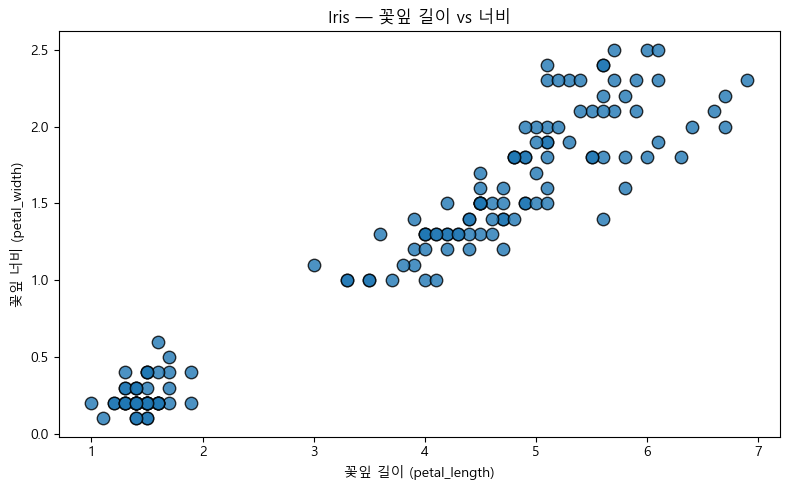

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df_iris['petal_length'], df_iris['petal_width'],
           s=80,                  # 마커 크기 (markersize가 아닌 s 사용)
           edgecolors='black',    # 마커 테두리 색상
           alpha=0.8)             # 투명도

ax.set_title('Iris — 꽃잎 길이 vs 너비')
ax.set_xlabel('꽃잎 길이 (petal_length)')
ax.set_ylabel('꽃잎 너비 (petal_width)')

plt.tight_layout()
plt.show()

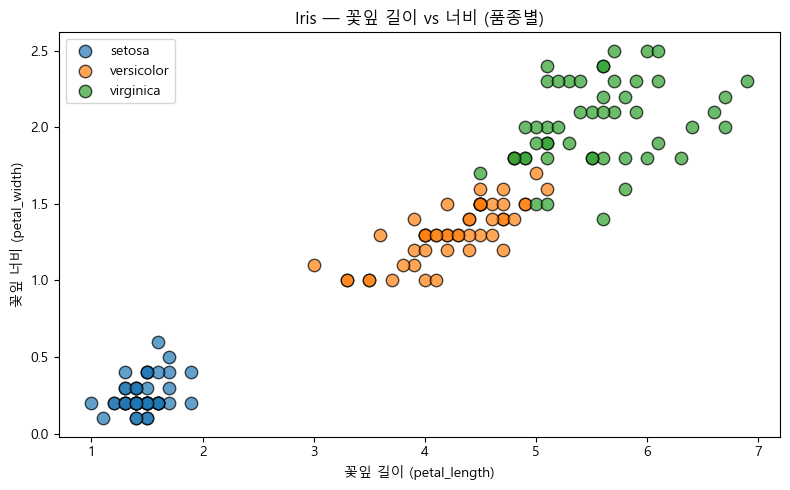

In [48]:
# species별로 루프를 돌며 각각 다른 색상으로 scatter
fig, ax = plt.subplots(figsize=(8, 5))

# mcolors.TABLEAU_COLORS.keys()는 tab: 접두사가 필요함
colors = {'setosa': 'tab:blue', 'versicolor': 'tab:orange', 'virginica': 'tab:green'}

for species, group in df_iris.groupby('species'):

    # 1번째 반복
    # species = 'setosa'
    # group   = setosa에 해당하는 50개 행의 DataFrame

    # 2번째 반복
    # species = 'versicolor'
    # group   = versicolor에 해당하는 50개 행의 DataFrame

    # 3번째 반복
    # species = 'virginica'
    # group   = virginica에 해당하는 50개 행의 DataFrame

    ax.scatter(group['petal_length'], group['petal_width'],
               s=80,
               color=colors[species],
               edgecolors='black',
               alpha=0.7,
               label=species)

ax.set_title('Iris — 꽃잎 길이 vs 너비 (품종별)')
ax.set_xlabel('꽃잎 길이 (petal_length)')
ax.set_ylabel('꽃잎 너비 (petal_width)')
ax.legend()

plt.tight_layout()
plt.show()

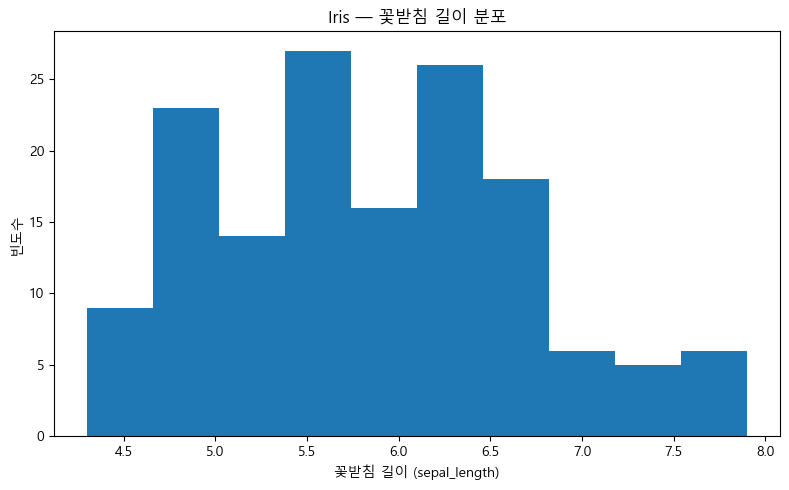

In [49]:
# fig.add_subplot() — Figure에 Axes를 하나씩 추가하는 방식
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(1, 1, 1)

ax.hist(df_iris['sepal_length'])

ax.set_title('Iris — 꽃받침 길이 분포')
ax.set_xlabel('꽃받침 길이 (sepal_length)')
ax.set_ylabel('빈도수')

plt.tight_layout()
plt.show()

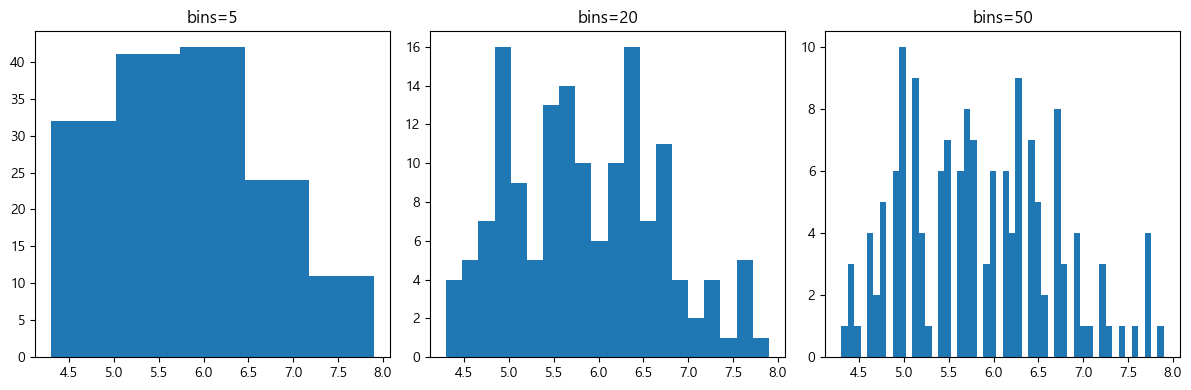

In [50]:
fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)


# 히스토그램은 데이터를 구간(bin)으로 나눠서 각 구간에 몇 개의 데이터가 있는지 막대로 표시
# bin 파라미터는  그 구간을 몇 개로 나눌지 결정
ax1.hist(df_iris['sepal_length'], bins=5)
ax2.hist(df_iris['sepal_length'], bins=20)
ax3.hist(df_iris['sepal_length'], bins=50)

ax1.set_title('bins=5')
ax2.set_title('bins=20')
ax3.set_title('bins=50')

plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_9136\1628353618.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([pclass1, pclass2, pclass3],


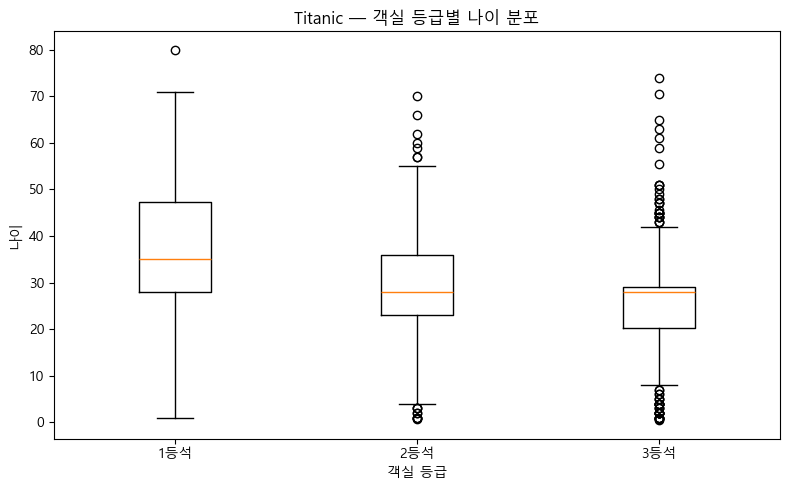

In [ ]:
# fig.add_subplot() — Figure에 Axes를 하나씩 추가하는 방식
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(1, 1, 1)

# 객실 등급별 나이 데이터를 리스트로 준비
pclass1 = df_titanic[df_titanic['Pclass'] == 1]['Age']
pclass2 = df_titanic[df_titanic['Pclass'] == 2]['Age']
pclass3 = df_titanic[df_titanic['Pclass'] == 3]['Age']

ax.boxplot([pclass1, pclass2, pclass3],# 가우넫 오렌지색이 중간 값 위에 동그란게 이상치(너무 작거나 큰 값)
           labels=['1등석', '2등석', '3등석'])

ax.set_title('Titanic — 객실 등급별 나이 분포')
ax.set_xlabel('객실 등급')
ax.set_ylabel('나이')

plt.tight_layout()
plt.show()

In [ ]:
# 사분위수 (Quartile)

# 데이터를 크기 순으로 정렬했을 때 4등분하는 기준값

# [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Q1 (25%) = 25   ← 하위 25% 지점
# Q2 (50%) = 55   ← 하위 50% 지점 = 중앙값(median)
# Q3 (75%) = 75   ← 하위 75% 지점

# IQR (Interquartile Range)
# IQR = Q3 - Q1  # 중간 50% 구간의 범위

# 이상치의 기준
# Q1 - 1.5 * IQR 미만
# 또는
# Q3 + 1.5 * IQR 초과

# Titanic 1등석 나이
# Q1  = 30   # 하위 25% 지점
# Q3  = 55   # 하위 75% 지점
# IQR = 55 - 30 = 25

# # 아래쪽 이상치 기준
# Q1 - 1.5 * IQR = 30 - 1.5 * 25 = 30 - 37.5 = -7.5

# 위쪽 이상치 기준
# Q3 + 1.5 * IQR = 55 + 1.5 * 25 = 55 + 37.5 = 92.5

# -7.5 미만인 나이  → 이상치 (나이가 음수일 수 없으므로 해당 없음)
# 92.5 초과인 나이  → 이상치 ← Boxplot에서 점으로 표시

In [52]:
# 생존자 vs 사망자 수 집계
survived = df_titanic['Survived'].value_counts()
survived


Survived
0    549
1    342
Name: count, dtype: int64

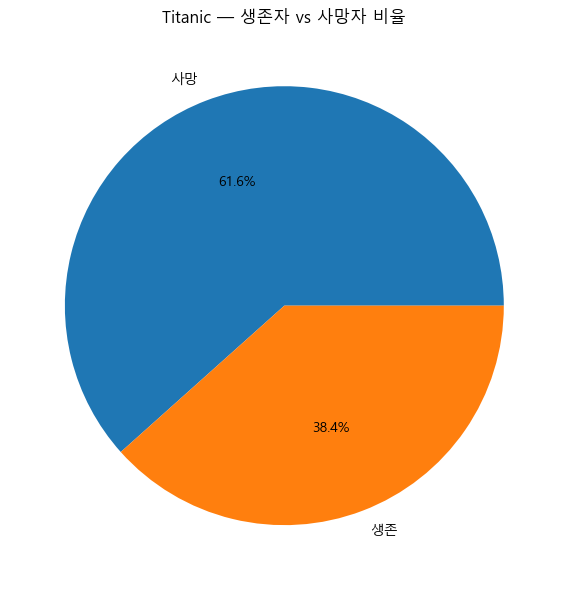

In [53]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)

ax.pie(survived.values,
       labels=['사망', '생존'],
       autopct='%1.1f%%')

# autopct: 각 조각 위에 비율(%)을 자동으로 계산해서 표시
# autopct='%1.1f%%'
# 전체 자릿수 최소 1자리
# .1는 소수점 이하 1자리
# %%는 % 기호 자체를 출력

ax.set_title('Titanic — 생존자 vs 사망자 비율')

plt.tight_layout()
plt.show()